In [ ]:
!pip install keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 6.4 MB/s eta 0:00:00


In [ ]:
import os
import glob
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from scipy.signal import spectrogram

In [ ]:
from google.colab import files
files.upload()


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"pooraniayswariyaps","key":"19bed4598ff7aab45cf59c4763d0f7f6"}'}

In [ ]:
import os
import shutil

os.makedirs("/root/.kaggle", exist_ok=True)
shutil.move("kaggle.json", "/root/.kaggle/kaggle.json")

os.chmod("/root/.kaggle/kaggle.json", 600)

print("Kaggle.json configured successfully!")

Kaggle.json configured successfully!


In [ ]:
!pip install kaggle


In [ ]:
!kaggle datasets download -d brjapon/cwru-bearing-datasets

Dataset URL: https://www.kaggle.com/datasets/brjapon/cwru-bearing-datasets
License(s): CC-BY-SA-4.0
  0% 0.00/40.4M [00:00<?, ?B/s]
100% 40.4M/40.4M [00:00<00:00, 1.60GB/s]


In [ ]:
import zipfile

zip_path = "cwru-bearing-datasets.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("CWRU_Dataset")

print("Dataset extracted successfully into CWRU_Dataset folder!")


Dataset extracted successfully into CWRU_Dataset folder!


In [ ]:
DATA_PATH = "CWRU_Dataset/raw/*.mat"
mat_files = glob.glob(DATA_PATH)

print("Total .mat files:", len(mat_files))

Total .mat files: 10


In [ ]:
def extract_signal_from_mat(file_path):
    mat_data = sio.loadmat(file_path)
    for key in mat_data.keys():
        if "DE_time" in key:
            return mat_data[key].flatten()
    raise ValueError("No DE_time found")

In [ ]:
def get_label_from_filename(file_path):
    filename = os.path.basename(file_path)

    if "Normal" in filename:
        return "Normal"
    elif filename.startswith("IR"):
        return "IR"
    elif filename.startswith("OR"):
        return "OR"
    elif filename.startswith("B"):
        return "B"
    else:
        return "Unknown"

In [ ]:
def segment_signal(signal, segment_size=2048):
    segments = []
    step = segment_size // 2

    for i in range(0, len(signal) - segment_size, step):
        seg = signal[i:i+segment_size]

        # Normalize each segment
        seg = (seg - np.mean(seg)) / (np.std(seg) + 1e-10)

        segments.append(seg)

    return np.array(segments)

In [ ]:
IMG_SIZE = 128

def signal_to_spectrogram(segment,
                          fs=12000,
                          nperseg=256,
                          noverlap=128):

    f, t, Sxx = spectrogram(
        segment,
        fs=fs,
        nperseg=nperseg,
        noverlap=noverlap
    )

    Sxx = np.log(Sxx + 1e-10)

    Sxx = (Sxx - Sxx.min()) / (
        Sxx.max() - Sxx.min() + 1e-10
    )

    Sxx = tf.image.resize(
        Sxx[..., np.newaxis],
        (IMG_SIZE, IMG_SIZE)
    ).numpy()

    return Sxx

In [ ]:
X = []
y = []

for file in mat_files:

    signal = extract_signal_from_mat(file)

    label = get_label_from_filename(file)

    if label == "Unknown":
        continue

    segments = segment_signal(signal)

    for seg in segments:

        img = signal_to_spectrogram(seg)

        X.append(img)

        y.append(label)


X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)

X shape: (4735, 128, 128, 1)


In [ ]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Classes:", label_encoder.classes_)

Classes: ['B' 'IR' 'Normal' 'OR']


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Train:", X_train.shape)
print("Test :", X_test.shape)

Train: (3788, 128, 128, 1)
Test : (947, 128, 128, 1)


In [ ]:
if len(X_train.shape) == 4:
    X_train = np.repeat(X_train, 3, axis=-1)
    X_test = np.repeat(X_test, 3, axis=-1)

print(X_train.shape)

(3788, 128, 128, 3)


In [ ]:
import keras_tuner as kt

ResNet50

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Model

IMG_SIZE = 128

base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)

feature_model = Model(
    inputs=base_model.input,
    outputs=x
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
x = base_model.output

x = GlobalAveragePooling2D()(x)

feature_model = Model(
    inputs=base_model.input,
    outputs=x
)

feature_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 64, 64,    │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 64, 64,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 64, 64,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 64, 64,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 64, 64,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 64, 64,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 65, 65,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 32, 32,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 32, 32,    │      2,304 │ block_1_depthwis

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
print("Extracting train features...")

features_train = feature_model.predict(
    X_train,
    batch_size=32,
    verbose=1
)

print("Train features shape:", features_train.shape)

Extracting train features...
119/119 ━━━━━━━━━━━━━━━━━━━━ 27s 110ms/step
Train features shape: (3788, 1280)


In [ ]:
print("Extracting test features...")

features_test = feature_model.predict(
    X_test,
    batch_size=32,
    verbose=1
)

print("Test features shape:", features_test.shape)

Extracting test features...
30/30 ━━━━━━━━━━━━━━━━━━━━ 11s 380ms/step
Test features shape: (947, 1280)


In [ ]:
time_steps = 32
feature_dim = 40

features_train = features_train.reshape(
    features_train.shape[0],
    time_steps,
    feature_dim
)

features_test = features_test.reshape(
    features_test.shape[0],
    time_steps,
    feature_dim
)

print("LSTM input:", features_train.shape)

LSTM input: (3788, 32, 40)


In [ ]:
print(features_train.shape)
print(features_test.shape)

(3788, 32, 40)
(947, 32, 40)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

features_train = scaler.fit_transform(
    features_train.reshape(-1, features_train.shape[-1])
).reshape(features_train.shape)

features_test = scaler.transform(
    features_test.reshape(-1, features_test.shape[-1])
).reshape(features_test.shape)

In [ ]:
for layer in base_model.layers[-20:]:
    layer.trainable = True

feature_model.compile(
    optimizer="adam",
    loss="mse"
)

print("Fine tuning enabled")

Fine tuning enabled


LSTM

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.optimizers import Adam

In [ ]:
def build_lstm_model(hp):

    model = Sequential()

    model.add(Input(shape=(32,40)))

    # Embedding layer added
    model.add(
        Dense(
            hp.Int(
                "embed_units",
                min_value=32,
                max_value=128,
                step=32
            ),
            activation="relu"
        )
    )

    # LSTM 1
    model.add(
        LSTM(
            units=hp.Int(
                "lstm1_units",
                min_value=32,
                max_value=128,
                step=32
            ),
            return_sequences=True
        )
    )

    model.add(BatchNormalization())

    # LSTM 2
    model.add(
        LSTM(
            units=hp.Int(
                "lstm2_units",
                min_value=32,
                max_value=128,
                step=32
            )
        )
    )

    model.add(BatchNormalization())

    model.add(
        Dropout(
            hp.Float(
                "dropout",
                0.2,
                0.5,
                step=0.1
            )
        )
    )

    model.add(
        Dense(
            hp.Int(
                "dense_units",
                64,
                256,
                step=64
            ),
            activation="relu"
        )
    )

    model.add(
        Dense(
            len(label_encoder.classes_),
            activation="softmax"
        )
    )

    model.compile(

        optimizer=Adam(
            hp.Choice(
                "lr",
                [1e-3, 1e-4]
            )
        ),

        loss="sparse_categorical_crossentropy",

        metrics=["accuracy"]
    )

    return model

In [ ]:
!rm -rf tuner_lstm

tuner_lstm = kt.RandomSearch(

    build_lstm_model,

    objective="val_accuracy",

    max_trials=5,

    executions_per_trial=1,

    directory="tuner_lstm",

    project_name="cwru_lstm"
)

In [ ]:
tuner_lstm.search(

    features_train,
    y_train,

    validation_data=(features_test, y_test),

    epochs=30,

    batch_size=32
)

Trial 5 Complete [00h 00m 50s]
val_accuracy: 0.9873284101486206

Best val_accuracy So Far: 0.9873284101486206
Total elapsed time: 00h 04m 19s


In [ ]:
best_lstm = tuner_lstm.get_best_models(1)[0]

best_lstm.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 30 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32, 64)         │        26,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 96)             │        61,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 96)             │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 102,276 (399.52 KB)

 Trainable params: 101,956 (398.27 KB)

 Non-trainable params: 320 (1.25 KB)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history_lstm = best_lstm.fit(
    features_train,
    y_train,
    validation_data=(features_test,y_test),
    epochs=30,
    batch_size=32,
    callbacks=[early]
)

Epoch 1/30
119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9986 - loss: 0.0058 - val_accuracy: 0.9863 - val_loss: 0.0594
Epoch 2/30
119/119 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9989 - loss: 0.0050 - val_accuracy: 0.9884 - val_loss: 0.0607
Epoch 3/30
119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9971 - loss: 0.0072 - val_accuracy: 0.9831 - val_loss: 0.0662
Epoch 4/30
119/119 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9986 - loss: 0.0053 - val_accuracy: 0.9863 - val_loss: 0.0559
Epoch 5/30
119/119 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.9982 - loss: 0.0066 - val_accuracy: 0.9799 - val_loss: 0.0998
Epoch 6/30
119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9969 - loss: 0.0069 - val_accuracy: 0.9588 - val_loss: 0.2048
Epoch 7/30
119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9960 - loss: 0.0097 - val_accuracy: 0.9831 - val_loss: 0.0559
Epoch 8/30
119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9958 - loss: 0.0110 - val_accu

In [ ]:
test_loss, test_acc = best_lstm.evaluate(
    features_test,
    y_test
)

print("LSTM Test Accuracy:", test_acc)

30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9861 - loss: 0.0799
LSTM Test Accuracy: 0.9862724542617798


30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


<Figure size 600x600 with 0 Axes>

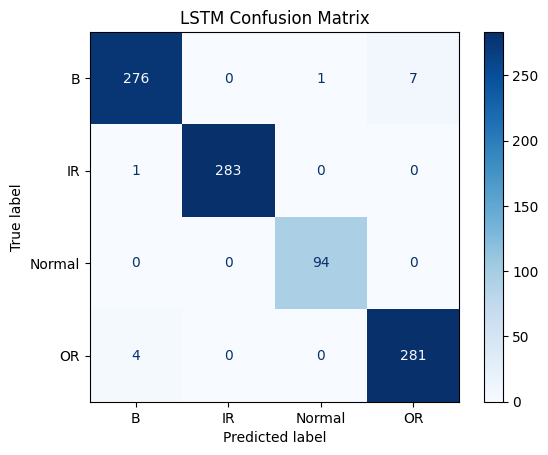

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

y_pred = np.argmax(
    best_lstm.predict(features_test),
    axis=1
)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

plt.figure(figsize=(6,6))
disp.plot(cmap="Blues")
plt.title("LSTM Confusion Matrix")
plt.show()

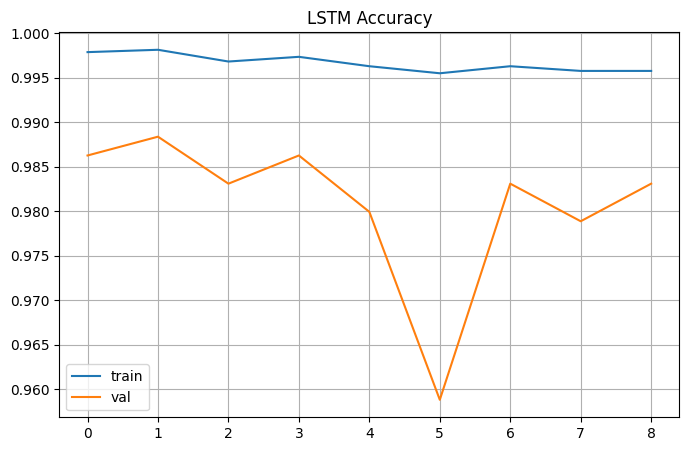

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    history_lstm.history["accuracy"],
    label="train"
)

plt.plot(
    history_lstm.history["val_accuracy"],
    label="val"
)

plt.legend()
plt.title("LSTM Accuracy")
plt.grid()
plt.show()